In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
# =================================
# Global Parameters
# =================================

# Network
n = 50         # number of nodes
mean_degree = 4
q_values = [0.0, 0.1, 1.0]

# Dynamics
gamma = 1.0
dt = 0.01
T_max = 100.0
epsilon_sync = 1e-3
omega_max = 2 * np.pi    # rad/s

# Power
P_value = 1.0

In [3]:
def generate_ws_network(n, mean_degree, q, seed=None) :
    """
    Generate a connected Watts-Strogatz network.

    Returns:
        G : networkx.Graph
        A : adjacency matrix (numpy array)
        edges : list of (k, 1) tuples with k < 1
    """
    while True:
        G = nx.watts_strogatz_graph(n, mean_degree, q, seed=seed)
        
        # Ensure the network is connected
        if nx.is_connected(G):
            break
            
    # Adjacency matrix
    A = nx.to_numpy_array(G)
    
    # Edge list (ensure k < 1)
    edges = [(int(u), int(v)) for u, v in G.edges() if u < v]
    
    return G, A, edges


In [4]:
G_test, A_test, edges_test = generate_ws_network( 
    n=n, 
    mean_degree=mean_degree,
    q=0.1,
    seed=1
) 


In [5]:
def assign_balanced_power(n, P=1.0, seed=None):
    """
    Assign balanced power injections:
    half generators (+P), half consumers (-P)
    
    Returns:
        P_vec : numpy array of length n
    """
    if seed is not None:
        np.random.seed(seed)
        
    if n % 2 != 0:
        raise ValueError("n must be even for balanced power assignment")
        
    P_vec = np.zeros(n)
    
    # Choose generator nodes
    generators = np.random.choice(n, size=n // 2, replace=False)
    
    # Assign power
    P_vec[generators] = P
    P_vec[P_vec == 0] = -P
    
    return P_vec

In [6]:
P_test = assign_balanced_power(n=n, P=1.0, seed=42)

print("P_k:", P_test)
print("Sum of P_k:", np.sum(P_test))
print("Number of generators:", np.sum(P_test > 0))
print("Number of consumers:", np.sum(P_test < 0))

P_k: [-1. -1. -1.  1.  1. -1.  1. -1.  1.  1. -1. -1.  1.  1. -1.  1.  1.  1.
 -1.  1. -1. -1. -1. -1.  1.  1.  1. -1. -1. -1.  1.  1.  1. -1.  1. -1.
 -1.  1. -1.  1. -1.  1. -1. -1. -1.  1.  1.  1.  1. -1.]
Sum of P_k: 0.0
Number of generators: 25
Number of consumers: 25


In [7]:
def get_neighbors(A):
    """
    From adjacency matrix A, return a list of neighbors for each node.
    """
    n = A.shape[0]
    neighbors = []
    for k in range(n):
        neighbors.append(np.where(A[k] > 0)[0])
    return neighbors

In [8]:
def swing_equations(t, x, P, A, neighbors, gamma, kappa):
    """
    Right-hand side of the swing equations.
    
    Parameters:
        t : time (not used explicitly, but required by solver)
        x : state vector [theta_1,...,theta_n, omega_1,...,omega_n]
        P : power vector (length n)
        A : adjacency matrix
        neighbors : list of neighbors for each node
        gamma : damping
        kappa : coupling strength
    """
    n = len(P)
    
    # Split state vector
    theta = x[:n]
    omega = x[n:]
    
    # Allocate derivatives
    dtheta_dt = omega
    domega_dt = np.zeros(n)
    
    # Compute domega/dt for each node
    for k in range(n):
        coupling_sum = 0.0
        for l in neighbors[k]:
            coupling_sum += np.sin(theta[k] - theta[l])
        
        domega_dt[k] = (
            P[k]
            - gamma * omega[k]
            - kappa * coupling_sum
        )
    
    # Combine derivatives
    dxdt = np.concatenate([dtheta_dt, domega_dt])
    
    return dxdt

In [9]:
from scipy.integrate import solve_ivp

In [10]:
def initial_conditions(n, seed=None):
    if seed is not None:
        np.random.seed(seed)
        
    theta0 = np.random.uniform(0, 2*np.pi, size=n)
    omega0 = np.zeros(n)
    
    return np.concatenate([theta0, omega0])

In [11]:
def integrate_swing(
    x0, P, A, neighbors, gamma, kappa, T_max, dt
):
    t_span = (0, T_max)
    t_eval = np.arange(0, T_max, dt)
    
    sol = solve_ivp(
        swing_equations,
        t_span,
        x0,
        t_eval=t_eval,
        args=(P, A, neighbors, gamma, kappa),
        rtol=1e-6,
        atol=1e-8
    )
    
    return sol

In [12]:
def is_synchronized(sol, n, epsilon):
    omega_final = sol.y[n:, -1]
    return np.max(np.abs(omega_final)) < epsilon

In [13]:
def find_steady_state(
    A, P, gamma, kappa, T_max, dt, epsilon, seed=None
):
    n = len(P)
    neighbors = get_neighbors(A)
    
    # Initial condition
    x0 = initial_conditions(n, seed=seed)
    
    # Integrate
    sol = integrate_swing(
        x0, P, A, neighbors, gamma, kappa, T_max, dt
    )
    
    # Check synchronization
    if not is_synchronized(sol, n, epsilon):
        return None
    
    # Extract steady state
    theta_star = sol.y[:n, -1]
    omega_star = sol.y[n:, -1]
    
    return theta_star, omega_star, sol

In [14]:
theta_star, omega_star, sol = find_steady_state(
    A=A_test,
    P=P_test,
    gamma=gamma,
    kappa=5.0,
    T_max=T_max,
    dt=dt,
    epsilon=epsilon_sync,
    seed=1
)

print("Max |omega*|:", np.max(np.abs(omega_star)))

Max |omega*|: 9.118091911385257e-08


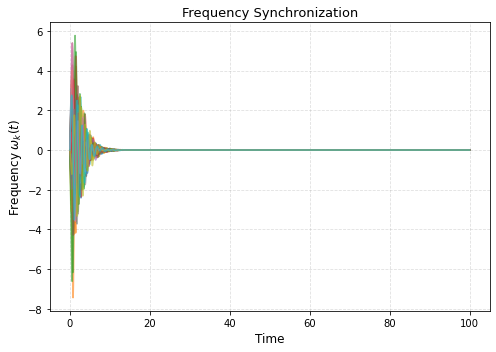

In [15]:
plt.figure(figsize=(7,5))

for k in range(n):
    plt.plot(sol.t, sol.y[n + k], alpha=0.6)

plt.xlabel("Time", fontsize=12)
plt.ylabel(r"Frequency $\omega_k(t)$", fontsize=12)
plt.title("Frequency Synchronization", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


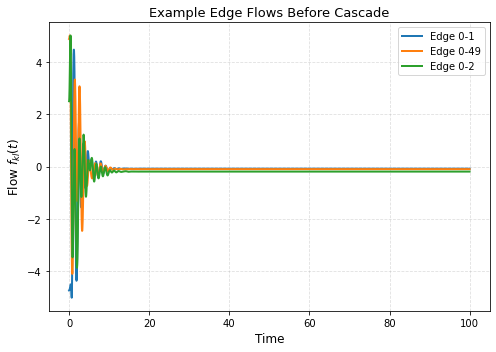

In [16]:
plt.figure(figsize=(7,5))

for (k, l) in edges_test[:3]:
    flow_time = 5.0 * np.sin(sol.y[k, :] - sol.y[l, :])
    plt.plot(sol.t, flow_time, linewidth=2, label=f"Edge {k}-{l}")

plt.xlabel("Time", fontsize=12)
plt.ylabel(r"Flow $f_{kl}(t)$", fontsize=12)
plt.title("Example Edge Flows Before Cascade", fontsize=13)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [17]:
def compute_edge_flows(theta, edges, kappa):
    flows = {}
    for (k, l) in edges:
        flows[(k, l)] = kappa * np.sin(theta[k] - theta[l])
    return flows

In [18]:
flows = compute_edge_flows(theta_star, edges_test, kappa=5.0)
alpha_star = max(abs(f) for f in flows.values())

print("alpha* =", alpha_star)

alpha* = 1.2675472705892092


In [19]:
def detect_line_overloads(theta, edges, kappa, alpha_star, alpha_ratio):
    """
    Detect overloaded edges.
    
    Returns:
        failed_edges : list of (k, l) tuples
    """
    alpha = alpha_ratio * alpha_star
    failed_edges = []
    
    for (k, l) in edges:
        flow = kappa * np.sin(theta[k] - theta[l])
        if abs(flow) > alpha:
            failed_edges.append((k, l))
    
    return failed_edges

In [20]:
failed_edges_test = detect_line_overloads(
    theta=theta_star,
    edges=edges_test,
    kappa=5.0,
    alpha_star=alpha_star,
    alpha_ratio=1.2
)

print("Failed edges:", failed_edges_test)

Failed edges: []


In [21]:
def detect_desync_nodes(omega, omega_max):
    """
    Detect nodes that desynchronize.
    
    Returns:
        failed_nodes : list of node indices
    """
    failed_nodes = []
    
    for k in range(len(omega)):
        if abs(omega[k]) > omega_max:
            failed_nodes.append(k)
    
    return failed_nodes

In [22]:
failed_nodes_test = detect_desync_nodes(
    omega=omega_star,
    omega_max=omega_max
)

print("Failed nodes:", failed_nodes_test)

Failed nodes: []


In [23]:
def find_most_loaded_edge(flows):
    """
    Identify the edge with the maximum absolute flow.
    
    Returns:
        edge_max : (k, l)
        max_flow : float
    """
    edge_max = max(flows, key=lambda e: abs(flows[e]))
    max_flow = flows[edge_max]
    
    return edge_max, max_flow

In [24]:
edge_max, max_flow = find_most_loaded_edge(flows)

print("Most loaded edge:", edge_max)
print("Flow on that edge:", max_flow)
print("Absolute flow:", abs(max_flow))

Most loaded edge: (18, 20)
Flow on that edge: 1.2675472705892092
Absolute flow: 1.2675472705892092


In [25]:
def remove_edge_from_list(edges, edge_to_remove):
    """
    Remove a single edge from the edge list.
    
    Returns:
        new_edges : updated edge list
    """
    return [e for e in edges if e != edge_to_remove]

In [26]:
edges_after = remove_edge_from_list(edges_test, edge_max)

print("Original number of edges:", len(edges_test))
print("After removal:", len(edges_after))

Original number of edges: 100
After removal: 99


In [27]:
def remove_edge_from_adjacency(A, edge_to_remove):
    """
    Remove a single edge from the adjacency matrix.
    
    Returns:
        A_new : updated adjacency matrix
    """
    A_new = A.copy()
    k, l = edge_to_remove
    A_new[k, l] = 0
    A_new[l, k] = 0
    return A_new

In [28]:
A_after = remove_edge_from_adjacency(A_test, edge_max)

print("Before:", A_test[edge_max[0], edge_max[1]])
print("After:", A_after[edge_max[0], edge_max[1]])

Before: 1.0
After: 0.0


In [29]:
def trigger_initial_failure(A, edges, flows):
    """
    Apply Algorithm 1: remove the most loaded edge.
    
    Returns:
        A_new : updated adjacency matrix
        edges_new : updated edge list
        removed_edge : the failed edge
    """
    removed_edge, max_flow = find_most_loaded_edge(flows)
    
    A_new = remove_edge_from_adjacency(A, removed_edge)
    edges_new = remove_edge_from_list(edges, removed_edge)
    
    return A_new, edges_new, removed_edge

In [30]:
A_cascade, edges_cascade, removed_edge = trigger_initial_failure(
    A_test, edges_test, flows
)

print("Initial failed edge:", removed_edge)
print("Edges remaining:", len(edges_cascade))

Initial failed edge: (18, 20)
Edges remaining: 99


In [31]:
def remove_nodes(A, edges, failed_nodes):
    """
    Remove nodes and all incident edges.
    
    Returns:
        A_new : updated adjacency matrix
        edges_new : updated edge list
    """
    A_new = A.copy()
    
    # Remove edges connected to failed nodes
    edges_new = []
    for (k, l) in edges:
        if (k not in failed_nodes) and (l not in failed_nodes):
            edges_new.append((k, l))
        else:
            A_new[k, l] = 0
            A_new[l, k] = 0
    
    # Zero rows and columns for failed nodes
    for k in failed_nodes:
        A_new[k, :] = 0
        A_new[:, k] = 0
    
    return A_new, edges_new

In [32]:
def cascade_step(
    x0,
    A,
    edges,
    P,
    gamma,
    kappa,
    alpha_star,
    alpha_ratio,
    omega_max,
    T_max,
    dt,
    epsilon
):
    n = len(P)
    neighbors = get_neighbors(A)
    
    # Integrate dynamics
    sol = integrate_swing(
        x0, P, A, neighbors, gamma, kappa, T_max, dt
    )
    
    alpha = alpha_ratio * alpha_star
    
    failed_edges = set()
    failed_nodes = set()
    
    for t_idx in range(sol.y.shape[1]):
        
        theta_t = sol.y[:n, t_idx]
        omega_t = sol.y[n:, t_idx]
    
        # Check edge overloads
        for (k, l) in edges:
            flow = kappa * np.sin(theta_t[k] - theta_t[l])
            if abs(flow) > alpha:
                failed_edges.add((k, l))
                
        # Check node desync
        for k in range(n):
            if abs(omega_t[k]) > omega_max:
                failed_nodes.add(k)
                
        # Early break
        if failed_edges or failed_nodes:
            break
                
    # Use final state as restart state
    theta_final = sol.y[:n, -1]
    omega_final = sol.y[n:, -1]
    
    return sol, theta_final, omega_final, list(failed_edges), list(failed_nodes)
            

In [33]:
def run_cascade(
    A_init,
    edges_init,
    x0,
    P,
    gamma,
    kappa,
    alpha_star,
    alpha_ratio,
    omega_max,
    T_max,
    dt,
    epsilon,
    gc_threshold=None   
):
    A = A_init.copy()
    edges = edges_init.copy()
    x = x0.copy()
    
    cascade_history = []
    termination_reason = None
    
    while True:
        sol, theta, omega, failed_edges, failed_nodes = cascade_step(
            x, A, edges, P, gamma, kappa,
            alpha_star, alpha_ratio, omega_max,
            T_max, dt, epsilon
        )
        
        # Record what happened
        cascade_history.append({
            "failed_edges": failed_edges,
            "failed_nodes": failed_nodes,
            "num_edges": len(edges)
        })
        
        # Stop condition: no new failures
        if (len(failed_edges) == 0) and (len(failed_nodes) == 0):
            termination_reason = "no_new_failures"
            break
        
        # Remove failed edges
        for e in failed_edges:
            A = remove_edge_from_adjacency(A, e)
            edges = remove_edge_from_list(edges, e)
        
        # Remove failed nodes
        if failed_nodes:
            A, edges = remove_nodes(A, edges, failed_nodes)
        
        # Restart from last state
        x = np.concatenate([theta, omega])
        
        # Total collapse guard
        if len(edges) == 0:
            termination_reason = "no_edges_remaining"
            break
            
    
    return A, edges, cascade_history, termination_reason

In [34]:
# Initial condition from steady state
x0_cascade = np.concatenate([theta_star, omega_star])

A_final, edges_final, history, termination_reason  = run_cascade(
    A_init=A_cascade,
    edges_init=edges_cascade,
    x0=x0_cascade,
    P=P_test,
    gamma=gamma,
    kappa=5.0,
    alpha_star=alpha_star,
    alpha_ratio=0.9,      # deliberately stressful
    omega_max=omega_max,
    T_max=20,
    dt=0.05,
    epsilon=epsilon_sync
)

print("Initial edges:", len(edges_cascade))
print("Final edges:", len(edges_final))
print("Cascade steps:", len(history))
print("Termination reason:", termination_reason)

Initial edges: 99
Final edges: 92
Cascade steps: 5
Termination reason: no_new_failures


In [35]:
for i, step in enumerate(history):
    print(
        f"Step {i}: "
        f"failed edges = {len(step['failed_edges'])}, "
        f"failed nodes = {len(step['failed_nodes'])}, "
        f"edges remaining = {step['num_edges']}"
    )

Step 0: failed edges = 1, failed nodes = 0, edges remaining = 99
Step 1: failed edges = 1, failed nodes = 0, edges remaining = 98
Step 2: failed edges = 3, failed nodes = 0, edges remaining = 97
Step 3: failed edges = 2, failed nodes = 0, edges remaining = 94
Step 4: failed edges = 0, failed nodes = 0, edges remaining = 92


In [36]:
import networkx as nx

def giant_component_fraction(A):
    """
    Compute fraction of nodes in largest connected component.
    """
    G = nx.from_numpy_array(A)
    
    if len(G.nodes) == 0:
        return 0.0
    
    components = list(nx.connected_components(G))
    largest = max(components, key=len)
    
    return len(largest) / len(G.nodes)

In [37]:
def compute_resilience(num_edges_final, num_edges_initial):
    """
    Compute resilience metric:
    S = |E_surviving| / |E_initial|
    """
    if num_edges_initial == 0:
        return 0.0
    return num_edges_final / num_edges_initial

In [38]:
def run_single_experiment(q, alpha_ratio, seed=None):
    """
    Run full cascade experiment for a given topology q.
    
    Returns:
        result_dict containing:
            S
            q
            alpha_ratio
            termination_reason
    """
    
    # --- Generate network ---
    G, A, edges = generate_ws_network(
        n=n,
        mean_degree=mean_degree,
        q=q,
        seed=seed
    )
    
    # --- Assign power ---
    P_vec = assign_balanced_power(n, P=P_value, seed=seed)
    
    # --- Find steady state ---
    steady = find_steady_state(
        A=A,
        P=P_vec,
        gamma=gamma,
        kappa=5.0,
        T_max=40,
        dt=dt,
        epsilon=epsilon_sync,
        seed=seed
    )
    
    if steady is None:
        return None  # did not synchronize
    
    theta_star, omega_star, sol = steady
    
    # --- Compute flows and alpha_star ---
    flows = compute_edge_flows(theta_star, edges, kappa=5.0)
    alpha_star = max(abs(f) for f in flows.values())
    
    # --- Trigger initial failure ---
    A_cascade, edges_cascade, removed_edge = trigger_initial_failure(
        A, edges, flows
    )
    
    x0_cascade = np.concatenate([theta_star, omega_star])
    
    # --- Run cascade ---
    A_final, edges_final, history, termination_reason = run_cascade(
        A_init=A_cascade,
        edges_init=edges_cascade,
        x0=x0_cascade,
        P=P_vec,
        gamma=gamma,
        kappa=5.0,
        alpha_star=alpha_star,
        alpha_ratio=alpha_ratio,
        omega_max=omega_max,
        T_max=T_max,
        dt=dt,
        epsilon=epsilon_sync
    )
    
    # --- Compute resilience ---
    S = compute_resilience(
        num_edges_final=len(edges_final),
        num_edges_initial=len(edges)
    )
    
    return {
        "S": S,
        "q": q,
        "alpha_ratio": alpha_ratio,
        "termination_reason": termination_reason,
        "num_steps": len(history)
    }


In [39]:
q_values = [0.0, 0.1, 1.0]

In [40]:
results = []

alpha_ratio_test = 0.9  # fixed stress level

for q in q_values:
    print(f"Running q = {q}")
    
    result = run_single_experiment(
        q=q,
        alpha_ratio=alpha_ratio_test,
        seed=1
    )
    
    if result is not None:
        results.append(result)

results

Running q = 0.0
Running q = 0.1
Running q = 1.0


[{'S': 0.8,
  'q': 0.0,
  'alpha_ratio': 0.9,
  'termination_reason': 'no_new_failures',
  'num_steps': 5},
 {'S': 0.71,
  'q': 0.1,
  'alpha_ratio': 0.9,
  'termination_reason': 'no_new_failures',
  'num_steps': 10},
 {'S': 0.17,
  'q': 1.0,
  'alpha_ratio': 0.9,
  'termination_reason': 'no_new_failures',
  'num_steps': 12}]

In [41]:
S_values = [r["S"] for r in results]
q_vals = [r["q"] for r in results]
termination_modes = [r["termination_reason"] for r in results]

print("Resilience S:", S_values)
print("Topology q:", q_vals)
print("Termination:", termination_modes)

Resilience S: [0.8, 0.71, 0.17]
Topology q: [0.0, 0.1, 1.0]
Termination: ['no_new_failures', 'no_new_failures', 'no_new_failures']


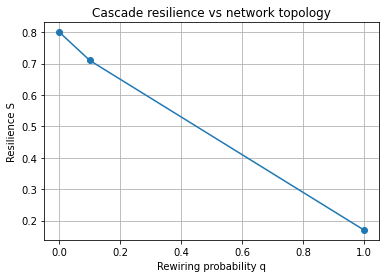

In [42]:
plt.figure(figsize=(6, 4))
plt.plot(q_vals, S_values, marker='o')
plt.xlabel("Rewiring probability q")
plt.ylabel("Resilience S")
plt.title("Cascade resilience vs network topology")
plt.grid(True)
plt.show()

In [43]:
# Fast sweep parameters (for laptop)

alpha_ratios = np.linspace(0.6, 1.6, 6)   # fewer stress levels
N_trials = 15                              

# Speed up integration slightly
T_max_fast = 40.0                         # shorter integration window

results_sweep = []

In [44]:
results_sweep = []

for q in q_values:
    print(f"\nRunning topology q = {q}")
    
    for alpha_ratio in alpha_ratios:
        
        S_trials = []
        termination_modes = []
        
        for trial in range(N_trials):

            result = run_single_experiment(
                q=q,
                alpha_ratio=alpha_ratio,
                seed=trial
            ) 
            

            if result is not None:
                S_trials.append(result["S"])
                termination_modes.append(result["termination_reason"])

        if len(S_trials) > 0:
            S_mean = np.mean(S_trials)
            S_std = np.std(S_trials)

            # Count termination types
            termination_counts = {}
            for mode in termination_modes:
                termination_counts[mode] = termination_counts.get(mode, 0) + 1
        else:
            S_mean = np.nan
            S_std = np.nan
            termination_counts = {}
        
        results_sweep.append({
            "q": q,
            "alpha_ratio": alpha_ratio,
            "S_mean": S_mean,
            "S_std": S_std,
            "num_trials": len(S_trials),
            "termination_counts": termination_counts
        })


Running topology q = 0.0

Running topology q = 0.1

Running topology q = 1.0


In [45]:
print("Termination summary:\n")

for r in results_sweep:
    print(
        f"q={r['q']}, alpha={r['alpha_ratio']:.2f} ->",
        r["termination_counts"]
    )


Termination summary:

q=0.0, alpha=0.60 -> {'no_new_failures': 15}
q=0.0, alpha=0.80 -> {'no_new_failures': 15}
q=0.0, alpha=1.00 -> {'no_new_failures': 15}
q=0.0, alpha=1.20 -> {'no_new_failures': 15}
q=0.0, alpha=1.40 -> {'no_new_failures': 15}
q=0.0, alpha=1.60 -> {'no_new_failures': 15}
q=0.1, alpha=0.60 -> {'no_new_failures': 15}
q=0.1, alpha=0.80 -> {'no_new_failures': 15}
q=0.1, alpha=1.00 -> {'no_new_failures': 15}
q=0.1, alpha=1.20 -> {'no_new_failures': 15}
q=0.1, alpha=1.40 -> {'no_new_failures': 15}
q=0.1, alpha=1.60 -> {'no_new_failures': 15}
q=1.0, alpha=0.60 -> {'no_new_failures': 15}
q=1.0, alpha=0.80 -> {'no_new_failures': 15}
q=1.0, alpha=1.00 -> {'no_new_failures': 15}
q=1.0, alpha=1.20 -> {'no_new_failures': 15}
q=1.0, alpha=1.40 -> {'no_new_failures': 15}
q=1.0, alpha=1.60 -> {'no_new_failures': 15}


In [46]:
# Separate results by q
results_by_q = {}

for q in q_values:
    results_by_q[q] = [r for r in results_sweep if r["q"] == q]

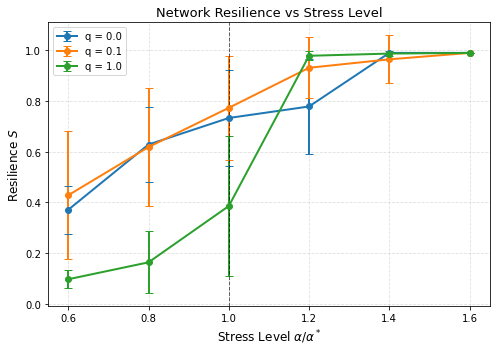

In [47]:
plt.figure(figsize=(7,5))

for q in q_values:
    
    data_q = [r for r in results_sweep if r["q"] == q]
    
    alpha_vals = [r["alpha_ratio"] for r in data_q]
    S_means = [r["S_mean"] for r in data_q]
    S_stds  = [r["S_std"]  for r in data_q]
    
    # Sort everything together by alpha
    alpha_vals, S_means, S_stds = zip(
        *sorted(zip(alpha_vals, S_means, S_stds))
    )
    
    plt.errorbar(
        alpha_vals,
        S_means,
        yerr=S_stds,
        marker='o',
        linewidth=2,
        capsize=4,
        label=f"q = {q}"
    )

plt.axvline(1.0, linestyle="--", linewidth=1, color="black", alpha=0.6)

plt.xlabel(r"Stress Level $\alpha / \alpha^*$", fontsize=12)
plt.ylabel(r"Resilience $S$", fontsize=12)
plt.title("Network Resilience vs Stress Level", fontsize=13)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



In [48]:
for r in results_sweep:
    print(
        f"q={r['q']}, alpha={r['alpha_ratio']:.2f}, std={r['S_std']}"
    )


q=0.0, alpha=0.60, std=0.09379883913046165
q=0.0, alpha=0.80, std=0.14786780883237868
q=0.0, alpha=1.00, std=0.1909508371864921
q=0.0, alpha=1.20, std=0.18902792268751079
q=0.0, alpha=1.40, std=1.1102230246251565e-16
q=0.0, alpha=1.60, std=1.1102230246251565e-16
q=0.1, alpha=0.60, std=0.2517370762433606
q=0.1, alpha=0.80, std=0.23208810587552495
q=0.1, alpha=1.00, std=0.20447222033540127
q=0.1, alpha=1.20, std=0.11993702051030318
q=0.1, alpha=1.40, std=0.09478865379827316
q=0.1, alpha=1.60, std=1.1102230246251565e-16
q=1.0, alpha=0.60, std=0.03492213560989012
q=1.0, alpha=0.80, std=0.12213653562031852
q=1.0, alpha=1.00, std=0.2766417659477084
q=1.0, alpha=1.20, std=0.018571184369578823
q=1.0, alpha=1.40, std=0.009977753031397186
q=1.0, alpha=1.60, std=1.1102230246251565e-16
